In [ ]:
##Predicting 2011-2020 Global Monthly Average Temperature Using Historical Data from 1970-2019
##Only Using Data from Stations with at least 45 years of data

In [1]:
###########
# STEP 1: Load PySpark functions and utilities
###########
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, year, month, avg, countDistinct, regexp_replace,
    round, when, create_map, lit
)
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator
from itertools import chain

###########
# STEP 2: Start Spark session and load data
###########
spark = SparkSession.builder.appName("GSOD Decade Temp Prediction").getOrCreate()
df = spark.read.parquet("/home/jovyan/Project/gsod_parquet_enriched")

# Add year and month columns
df = df.withColumn("year", year("DATE")).withColumn("month", month("DATE"))

###########
# STEP 3: Clean and filter data
###########
df_clean = df.filter(
    (col("TEMP").isNotNull()) &
    (col("LATITUDE").isNotNull()) & (col("LONGITUDE").isNotNull()) &
    (col("ELEVATION").isNotNull()) &
    (col("PRCP").isNotNull()) & (col("PRCP") < 99.99) &
    (col("SLP").isNotNull()) & (col("SLP") < 9999) &
    (col("WDSP").isNotNull()) & (col("WDSP") < 999.9)
)

df_recent = df_clean.filter((col("year") >= 1970) & (col("year") <= 2023))

# Keep only stations with 45+ years of data
station_counts = df_recent.groupBy("STATION").agg(countDistinct("year").alias("year_count"))
valid_stations = station_counts.filter(col("year_count") >= 45)
df_filtered = df_recent.join(valid_stations, on="STATION", how="inner")

###########
# STEP 4: Aggregate to monthly average per station
###########
df_monthly = df_filtered.groupBy(
    "STATION", "LATITUDE", "LONGITUDE", "ELEVATION", "year", "month"
).agg(
    avg("TEMP").alias("AVG_TEMP"),
    avg("PRCP").alias("AVG_PRCP"),
    avg("SLP").alias("AVG_SLP"),
    avg("WDSP").alias("AVG_WDSP")
)

df_monthly = df_monthly.dropna(subset=[
    "LATITUDE", "LONGITUDE", "ELEVATION", "year", "month",
    "AVG_TEMP", "AVG_PRCP", "AVG_SLP", "AVG_WDSP"
])

###########
# STEP 5: Feature engineering
###########
assembler = VectorAssembler(
    inputCols=["LATITUDE", "LONGITUDE", "ELEVATION", "year", "month", "AVG_PRCP", "AVG_SLP", "AVG_WDSP"],
    outputCol="features"
)

data = assembler.transform(df_monthly).select("features", "AVG_TEMP", "year", "month")

# Split training and test data by decade
train = data.filter(col("year") < 2010)
test = data.filter((col("year") >= 2011) & (col("year") <= 2020))

###########
# STEP 6: Train Gradient Boosted Tree Model
###########
gbt = GBTRegressor(labelCol="AVG_TEMP", featuresCol="features", maxIter=100, maxDepth=5, subsamplingRate=0.8)
model = gbt.fit(train)

###########
# STEP 7: Evaluate Model
###########
predictions = model.transform(test).cache()

evaluator_rmse = RegressionEvaluator(labelCol="AVG_TEMP", predictionCol="prediction", metricName="rmse")
evaluator_r2 = RegressionEvaluator(labelCol="AVG_TEMP", predictionCol="prediction", metricName="r2")
evaluator_mae = RegressionEvaluator(labelCol="AVG_TEMP", predictionCol="prediction", metricName="mae")

rmse = evaluator_rmse.evaluate(predictions)
r2 = evaluator_r2.evaluate(predictions)
mae = evaluator_mae.evaluate(predictions)

print("RMSE Results:")
print(f"  Train RMSE : {evaluator_rmse.evaluate(model.transform(train)):.2f}")
print(f"  Test RMSE  : {rmse:.2f}")
print(f"  Test R²    : {r2:.2f}")
print(f"  Test MAE   : {mae:.2f}")

###########
# STEP 8: Monthly Comparison (2011–2020)
###########
month_map = dict(zip(range(1, 13), ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                                    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]))
mapping_expr = create_map([lit(x) for x in chain(*month_map.items())])

# Add readable month names and aggregate
monthly_comparison = predictions.withColumn("month_name", mapping_expr[col("month")]) \
    .groupBy("month", "month_name").agg(
        round(avg("AVG_TEMP"), 2).alias("actual_avg_temp"),
        round(avg("prediction"), 2).alias("predicted_avg_temp")
    ).orderBy("month")

# Show the monthly comparison
print("\n 2011–2020 Monthly Average Temperature: Actual vs. Predicted\n")
monthly_comparison.select("month_name", "actual_avg_temp", "predicted_avg_temp").show()


RMSE Results:
  Train RMSE : 3.73
  Test RMSE  : 3.84
  Test R²    : 0.97
  Test MAE   : 2.76

 2011–2020 Monthly Average Temperature: Actual vs. Predicted

+----------+---------------+------------------+
|month_name|actual_avg_temp|predicted_avg_temp|
+----------+---------------+------------------+
|       Jan|          39.49|             39.38|
|       Feb|          41.95|              41.9|
|       Mar|          48.63|             48.24|
|       Apr|          56.31|             55.83|
|       May|          63.16|             62.67|
|       Jun|          68.67|              68.5|
|       Jul|          71.63|             70.99|
|       Aug|          70.89|             70.44|
|       Sep|          65.57|             65.33|
|       Oct|          57.61|             57.41|
|       Nov|          48.85|             48.61|
|       Dec|          42.27|             42.16|
+----------+---------------+------------------+



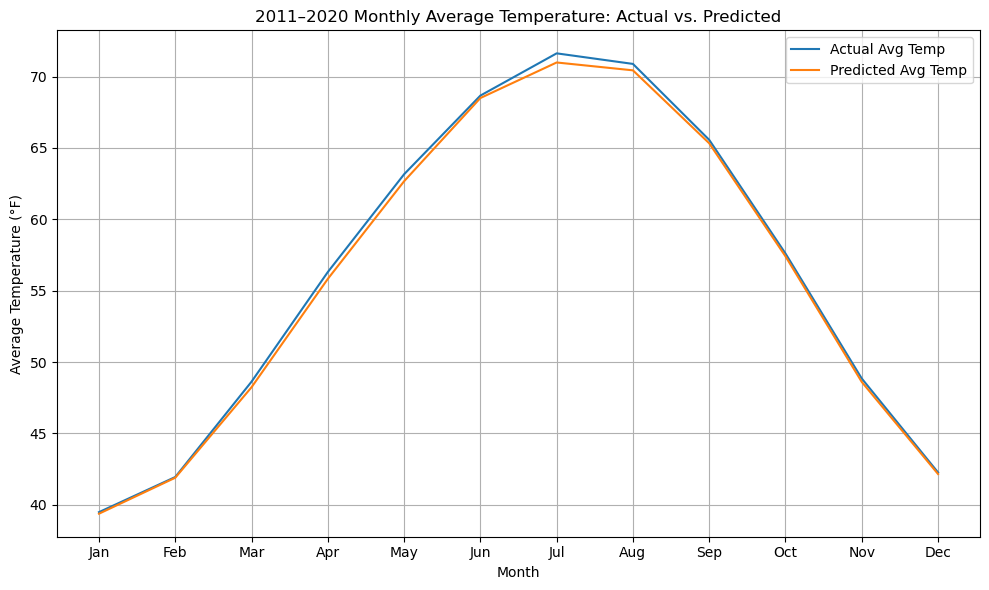

In [2]:
import matplotlib.pyplot as plt

monthly_pd = monthly_comparison.select(
    "month_name", "actual_avg_temp", "predicted_avg_temp"
).orderBy("month").toPandas()

plt.figure(figsize=(10, 6))
plt.plot(monthly_pd["month_name"], monthly_pd["actual_avg_temp"], label="Actual Avg Temp")
plt.plot(monthly_pd["month_name"], monthly_pd["predicted_avg_temp"], label="Predicted Avg Temp")
plt.title("2011–2020 Monthly Average Temperature: Actual vs. Predicted")
plt.xlabel("Month")
plt.ylabel("Average Temperature (°F)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("figure1_monthly_actual_vs_predicted.png", dpi=300)
plt.show()
